DATASET PREVIEW
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset Shape:
(200, 5)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7

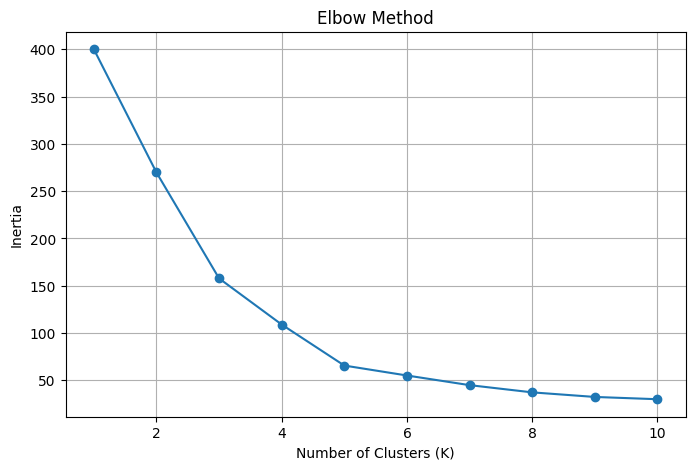


Cluster Counts:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

Cluster Centers (Scaled Data):
[[-0.20091257 -0.02645617]
 [ 0.99158305  1.23950275]
 [-1.32954532  1.13217788]
 [ 1.05500302 -1.28443907]
 [-1.30751869 -1.13696536]]


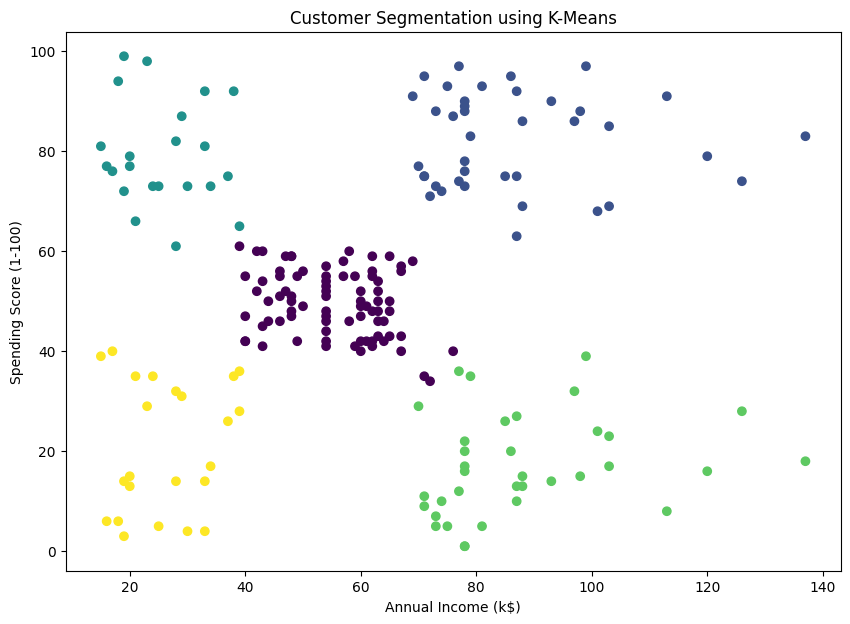


Results saved successfully.


In [1]:
#==========================================================CUSTOMER SEGMENTATION USING K-MEANS CLUSTERING================================================================

#IMPORTING LIBRARIES
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

#LOADING DATA
df = pd.read_csv("sample_data/Mall_Customers.csv")
print("=" * 50)
print("DATASET PREVIEW")
print("=" * 50)
print(df.head())

#BASIC DATA INSPECTION
print("\nDataset Shape:")
print(df.shape)
print("\nDataset Information:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nStatistical Summary:")
print(df.describe())

#SELECT FEATURES
X = df[["Annual Income (k$)","Spending Score (1-100)"]]

#FEATURE SCALING
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#MINIMIZING INERTIA USING ELBOW METHOD
inertias = []
for k in range(1, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(X_scaled)
    inertias.append(model.inertia_)

#PLOTING INERTIA CURVE
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, 11),
    inertias,
    marker="o"
)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

#FINAL MODEL
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)
kmeans.fit(X_scaled)

#ASSIGN CLUSTERS AND CENTERS
df["Cluster"] = kmeans.labels_
print("\nCluster Counts:")
print(df["Cluster"].value_counts().sort_index())

print("\nCluster Centers (Scaled Data):")
print(kmeans.cluster_centers_)

#PLOT CLUSTERS
plt.figure(figsize=(10, 7))
plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"]
)
plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()

#SAVING
df.to_csv(
    "customer_segments.csv",
    index=False
)
print("\nResults saved successfully.")